# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

When we fit a model purely by minimizing MSE, the model is free to make coefficients as large as it wants to chase the training data, including its noise. Adding a penalty that grows with the size of the coefficients forces the optimizer to balance two competing goals: fitting the data well and keeping the parameters small. The result is a model that's less willing to contort itself to fit every quirk in the training set, which generally means it generalizes better to new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

The penalty strength α (or λ) acts as a dial. When α = 0, you get ordinary least squares: low bias, potentially high variance. As you increase α, the model's coefficients are pushed toward zero, which introduces bias (the model is constrained and can't fit the data as closely) but reduces variance (the coefficients are more stable across different training samples). By sweeping α across a range, you're literally traversing the bias-variance curve and can find a sweet spot where total prediction error is minimized.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Both add a penalty, but they differ in form: Ridge penalizes the sum of squared coefficients (L2 norm), while LASSO penalizes the sum of absolute values (L1 norm). This geometric difference has a big practical consequence: Ridge shrinks all coefficients toward zero but rarely to exactly zero, so all predictors stay in the model. LASSO can shrink coefficients to exactly zero, producing a sparse model that effectively performs variable selection. If you have many irrelevant features, LASSO will zero them out; Ridge will just make them small.

4. How do we typically scale variables for use in regularized regression? Why?

Variables should be standardized (subtract the mean, divide by the standard deviation) before fitting. The reason is that the penalty treats all coefficients equally and doesn't care about the underlying units. If one predictor is measured in millimeters and another in kilometers, their raw coefficients are on completely different scales, and the penalty would unfairly shrink the large-unit variable's coefficient much more. Standardizing puts all predictors on the same footing so the penalty applies evenly.

5. How is the penalty $\alpha$ typically selected?

α is treated as a hyperparameter and selected via cross-validation (usually k-fold). You fit the model across a grid of α values and evaluate prediction error on the held-out folds for each. The α that yields the lowest average cross-validated error is chosen. In practice, tools like RidgeCV or LassoCV in scikit-learn automate this.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No. You evaluate using plain MSE on the held-out fold only, without the penalty term. The penalty is a regularization device to constrain fitting, not a component of true prediction error. What you actually care about is how well the model predicts unseen outcomes, and the penalty doesn't enter into that calculation. Including it would conflate the regularization constraint with actual predictive loss, making it harder to compare models or select α meaningfully.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from google.colab import files
import io


In [ ]:
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['cars_hw.csv']))

Saving cars_hw.csv to cars_hw.csv


In [ ]:
# ── 1. Load data and create Age variable ──────────────────────────────────────
df = pd.read_csv('cars_hw.csv')

df['Age'] = 2025 - df['Make_Year']

X_raw = df[['Mileage_Run', 'Age']]
y = df['Price']

# (a) Third-degree polynomial expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# (b) Z-score normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [ ]:
# ── 2. Linear regression: sign of Mileage_Run x Age interaction ──────────────
lr = LinearRegression()
lr.fit(X_scaled, y)

lr_coefs = pd.Series(lr.coef_, index=feature_names)
print("Linear Regression Coefficients:")
print(lr_coefs)
interaction_val = lr_coefs['Mileage_Run Age']
print(f"\nInteraction (Mileage_Run x Age): {interaction_val:.4f}")
print(f"Sign: {'positive' if interaction_val > 0 else 'negative'}")

Linear Regression Coefficients:
Mileage_Run          7.861191e+05
Age                 -2.141229e+05
Mileage_Run^2       -1.783803e+05
Mileage_Run Age     -1.453125e+06
Age^2                2.789820e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.109725e+05
Mileage_Run Age^2    6.186680e+05
Age^3               -1.724494e+05
dtype: float64

Interaction (Mileage_Run x Age): -1453124.9641
Sign: negative


In [ ]:
# ── 3. LassoCV with 20-fold CV ────────────────────────────────────────────────
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso_cv.fit(X_scaled, y)
print(f"\nOptimal alpha: {lasso_cv.alpha_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 113886852965.03125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 132795967206.25, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 134831568431.84375, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Object


Optimal alpha: 112.8838


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 74097348355.03125, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 80797732276.96875, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 81100411903.65625, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergence

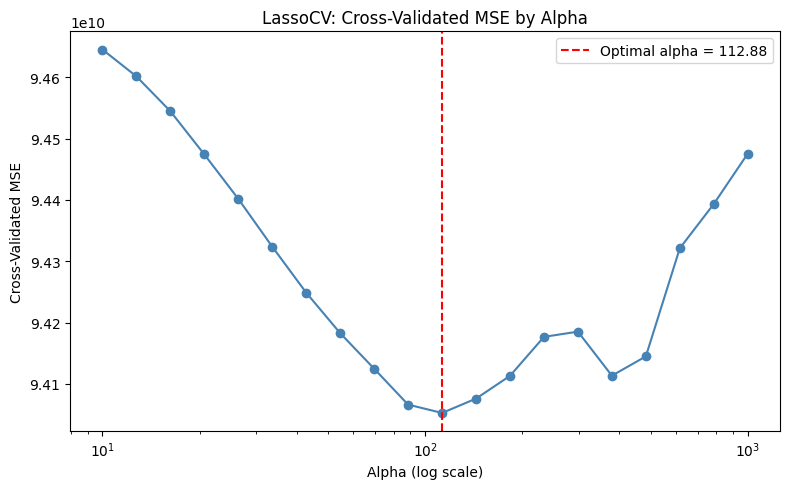

In [ ]:
# ── 4. Plot cross-validated MSE by alpha ─────────────────────────────────────
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mse_mean, marker='o', color='steelblue')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--',
            label=f'Optimal alpha = {lasso_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LassoCV: Cross-Validated MSE by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.144e+12, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.615e+12, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.230e+12, tolerance: 1.316e

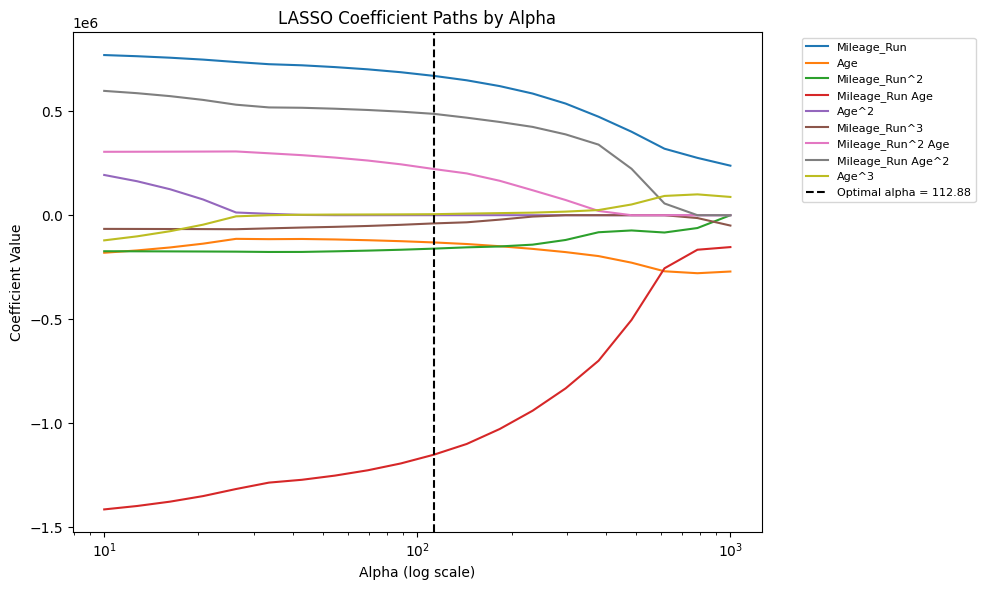

In [ ]:
# ── 5. Plot coefficient paths by alpha ───────────────────────────────────────
coef_paths = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(10, 6))
for i, name in enumerate(feature_names):
    plt.plot(alphas, coef_paths[:, i], label=name)
plt.axvline(lasso_cv.alpha_, color='black', linestyle='--',
            label=f'Optimal alpha = {lasso_cv.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths by Alpha')
plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6. Which features are selected? ──────────────────────────────────────────
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
selected = lasso_coefs[lasso_coefs != 0]
zeroed   = lasso_coefs[lasso_coefs == 0]

print("\nSelected features:")
print(selected)
print(f"\nZeroed out: {len(zeroed)} / {len(lasso_coefs)} ({len(zeroed)/len(lasso_coefs):.2%})")


Selected features:
Mileage_Run          6.700829e+05
Age                 -1.309727e+05
Mileage_Run^2       -1.607844e+05
Mileage_Run Age     -1.151929e+06
Mileage_Run^3       -3.945806e+04
Mileage_Run^2 Age    2.221205e+05
Mileage_Run Age^2    4.874554e+05
Age^3                4.838281e+03
dtype: float64

Zeroed out: 1 / 9 (11.11%)


In [ ]:
# ── 7. Compare LR vs LASSO coefficients ──────────────────────────────────────
comparison = pd.DataFrame({
    'LinearRegression': lr_coefs,
    'LASSO': lasso_coefs
})
comparison['magnitude_increased'] = comparison['LASSO'].abs() > comparison['LinearRegression'].abs()
comparison['sign_changed'] = np.sign(comparison['LASSO']) != np.sign(comparison['LinearRegression'])

print("\nCoefficient Comparison:")
print(comparison.to_string())
print(f"\nMagnitude increased: {comparison['magnitude_increased'].sum()}")
print(f"Sign changed: {comparison['sign_changed'].sum()}")


Coefficient Comparison:
                   LinearRegression         LASSO  magnitude_increased  sign_changed
Mileage_Run            7.861191e+05  6.700829e+05                False         False
Age                   -2.141229e+05 -1.309727e+05                False         False
Mileage_Run^2         -1.783803e+05 -1.607844e+05                False         False
Mileage_Run Age       -1.453125e+06 -1.151929e+06                False         False
Age^2                  2.789820e+05  0.000000e+00                False          True
Mileage_Run^3         -6.514490e+04 -3.945806e+04                False         False
Mileage_Run^2 Age      3.109725e+05  2.221205e+05                False         False
Mileage_Run Age^2      6.186680e+05  4.874554e+05                False         False
Age^3                 -1.724494e+05  4.838281e+03                False          True

Magnitude increased: 0
Sign changed: 2


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from google.colab import files
import io

In [28]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))


Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (6).csv


In [30]:
# Continuous features for polynomial expansion
cont_cols = ['age', 'ejection_fraction', 'serum_creatinine']
# Categorical/dummy features for interaction only
cat_cols  = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
# Target
y = df['DEATH_EVENT']

# (a) Third-degree polynomial expansion of continuous features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly.fit_transform(df[cont_cols])
cont_names = poly.get_feature_names_out(cont_cols)

# (b) Z-score normalize the polynomial features
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

# (c) Interaction-only expansion of categorical features
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(df[cat_cols])
cat_names = poly_cat.get_feature_names_out(cat_cols)

# (d) Concatenate into final feature matrix
X = np.hstack([X_cont_scaled, X_cat])
feature_names = list(cont_names) + list(cat_names)

print(f"\nTotal features: {len(feature_names)}")
print(feature_names)


Total features: 29
['age', 'ejection_fraction', 'serum_creatinine', 'age^2', 'age ejection_fraction', 'age serum_creatinine', 'ejection_fraction^2', 'ejection_fraction serum_creatinine', 'serum_creatinine^2', 'age^3', 'age^2 ejection_fraction', 'age^2 serum_creatinine', 'age ejection_fraction^2', 'age ejection_fraction serum_creatinine', 'age serum_creatinine^2', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction serum_creatinine^2', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'smoking', 'anaemia diabetes', 'anaemia high_blood_pressure', 'anaemia smoking', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']


In [31]:
# ── 2. Linear regression ──────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X, y)

lr_coefs = pd.Series(lr.coef_, index=feature_names)
print("\nLinear Regression Coefficients:")
print(lr_coefs.to_string())


Linear Regression Coefficients:
age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.07215

In [32]:
# ── 3. LassoCV with 20-fold CV ────────────────────────────────────────────────
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X, y)
print(f"\nOptimal alpha: {lasso_cv.alpha_:.6f}")


Optimal alpha: 0.005736


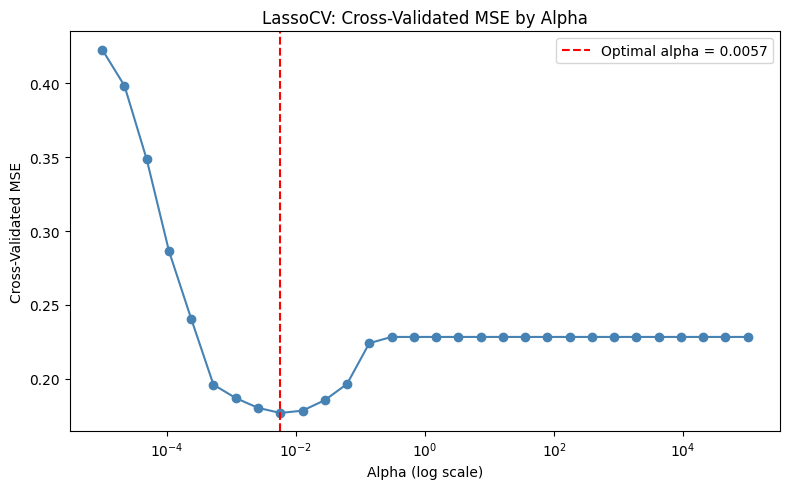

In [33]:
# ── 4. Plot cross-validated MSE by alpha ─────────────────────────────────────
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mse_mean, marker='o', color='steelblue')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--',
            label=f'Optimal alpha = {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LassoCV: Cross-Validated MSE by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

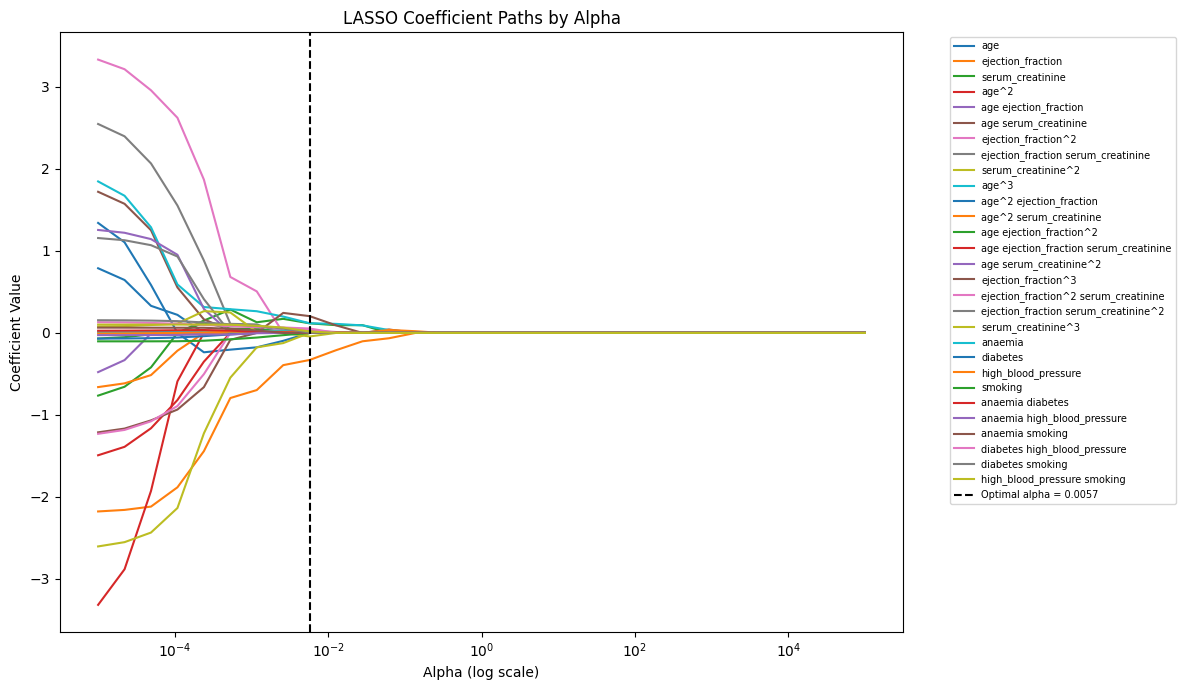

In [35]:
# ── 5. Plot coefficient paths by alpha ───────────────────────────────────────
coef_paths = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 7))
for i, name in enumerate(feature_names):
    plt.plot(alphas, coef_paths[:, i], label=name)
plt.axvline(lasso_cv.alpha_, color='black', linestyle='--',
            label=f'Optimal alpha = {lasso_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths by Alpha')
plt.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [36]:
# ── 6. Feature selection and comparison ──────────────────────────────────────
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
selected = lasso_coefs[lasso_coefs != 0]
zeroed   = lasso_coefs[lasso_coefs == 0]

print("\nSelected features (non-zero):")
print(selected.to_string())
print(f"\nZeroed out: {len(zeroed)} / {len(lasso_coefs)} ({len(zeroed)/len(lasso_coefs):.2%})")

comparison = pd.DataFrame({
    'LinearRegression': lr_coefs,
    'LASSO': lasso_coefs
})
comparison['magnitude_increased'] = comparison['LASSO'].abs() > comparison['LinearRegression'].abs()
comparison['sign_changed'] = (
    (np.sign(comparison['LASSO']) != np.sign(comparison['LinearRegression'])) &
    (comparison['LASSO'] != 0)  # ignore zeroed-out ones
)

print("\nCoefficient Comparison:")
print(comparison.to_string())
print(f"\nCoefficients that increased in magnitude: {comparison['magnitude_increased'].sum()}")
print(f"Coefficients that changed sign (non-zero only): {comparison['sign_changed'].sum()}")


Selected features (non-zero):
ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805

Zeroed out: 17 / 29 (58.62%)

Coefficient Comparison:
                                        LinearRegression     LASSO  magnitude_increased  sign_changed
age                                             1.539156 -0.000000                False         False
ejection_fraction                              -2.192494 -0.329656                False         False
serum_creatinine    

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

### 1. Objective Function

The ridge objective adds the penalty to MSE:

$$L(b_0, b_1) = \frac{1}{n}\sum_{i=1}^{n}(\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha b_1^2$$

### 2. Derivatives and Solution

Derivative with respect to $b_0$, set to zero:

$$-\frac{2}{n}\sum(\tilde{y}_i - b_0 - b_1\tilde{x}_i) = 0$$

Since $\tilde{x}$ and $\tilde{y}$ are mean-centered, this gives $b_0 = 0$.

Derivative with respect to $b_1$, set to zero:

$$-\frac{2}{n}\sum \tilde{x}_i(\tilde{y}_i - b_1\tilde{x}_i) + 2\alpha b_1 = 0$$

Solving for $b_1$:

$$b_1 = \frac{\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum \tilde{x}_i^2 + \alpha}$$

The numerator is the sample covariance of $x$ and $y$. The denominator is the variance of $x$ plus the penalty.

### 3. Effect of Increasing $\alpha$

As $\alpha$ increases, the denominator grows while the numerator stays fixed, so $b_1$ is pushed toward zero. When $\alpha = 0$ you recover OLS. As $\alpha \to \infty$, $b_1 \to 0$.

### 4. LASSO / L1 Challenge

With the L1 penalty the objective becomes:

$$L(b_0, b_1) = \frac{1}{n}\sum(\tilde{y}_i - b_0 - b_1\tilde{x}_i)^2 + \alpha|b_1|$$

The problem is that $|b_1|$ is **not differentiable at $b_1 = 0$**. You need a subgradient instead. The solution is soft thresholding:

$$b_1 = \text{sign}(\hat{b}_1^{OLS})\left(|\hat{b}_1^{OLS}| - \alpha\right)_+$$

It is optimal to set $b_1 = 0$ when:

$$\left|\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i\right| \leq \alpha$$

If the covariance between $x$ and $y$ is smaller in absolute value than $\alpha$, LASSO zeros out the coefficient. This is why LASSO produces sparse models while ridge does not.